# Octahedral Patchy Particles

We write a basic implementation of octahedral patchy particles with colored interactions to encode for the octahedral DNA self-assembly of particles. The particles are composed of two particle types: **central particles** (which are the DNA origami frame, essentially) and **patches** (which are the particles representing the ssDNA strands emitted at the vertices).

In [50]:
%pip install jax-md


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import jax.numpy as jnp
from jax import config
import jax
config.update("jax_enable_x64", True) # necessary for 64-bit precision

from jax import jit, random, grad, value_and_grad, remat, jacfwd, vmap, lax
from jax.example_libraries import optimizers
from jax_md import space, smap, energy, minimize, quantity, simulate, partition, rigid_body, util
# from jax_md.colab_tools import renderer
from jax_md import partition

import numpy as np

## Construction of octahedron

Let us construct a `rigid_body.point_union_shape` to represent the octahedral patchy particle, then visualize it. For the purposes of this demo, I will assign four particles on the equatorial ring (arbitrarily defined) with a species A and the remaining two particles on the poles with a species B.

In [2]:
# Constructs a single octahedral patchy particle as a RigidPointUnion — a rigid body
# described as a fixed union of point masses in body-frame coordinates.
#
# Each particle has 7 sites:
#   - 1 central site  (species 0): represents the DNA origami frame body
#   - 6 patch sites   (species 1): represent the 6 ssDNA sticky-end vertices
#     placed at ±RADIUS along each axis of the octahedron
#
# The energy functions later use these species labels to assign different interaction
# potentials to each type (LJ repulsion for centers, Morse attraction for patches).
def octahedron_shape(radius=0.5):
    particle_positions = jnp.array([
        [0.0,    0.0,    0.0],    # central site (origin of body frame)
        [radius, 0.0,    0.0],    # +x patch
        [-radius,0.0,    0.0],    # -x patch
        [0.0,    radius, 0.0],    # +y patch
        [0.0,   -radius, 0.0],    # -y patch
        [0.0,    0.0,    radius], # +z patch
        [0.0,    0.0,   -radius], # -z patch
    ], dtype=jnp.float64)

    # Species labels used to select rows/columns of the interaction epsilon matrices.
    # 0 = central site, 1 = patch site (all six patches treated as the same species here).
    particle_species = jnp.array([0, 1, 1, 1, 1, 1, 1], dtype=jnp.int32)

    # Patch masses are set to ~1e-8 (much smaller than the central mass of 1.0).
    # This keeps the centre of mass and principal axes essentially at the central site,
    # avoiding near-singular force gradients when patches overlap.
    # NOTE: this makes the moment of inertia tiny (~I ~ 2e-7), so the Langevin
    # integrator overdamps rotations; orientational DOF won't thermalize correctly
    # at the chosen dt. The translational dynamics are unaffected.
    patch_masses = jnp.linspace(0.1, 1.0, 6) * 1e-8
    masses = jnp.concatenate((jnp.array([1.0]), patch_masses), axis=0)

    # point_union_shape bundles the body-frame positions and masses into the
    # RigidPointUnion dataclass that JAX-MD's rigid-body integrator expects.
    shape = rigid_body.point_union_shape(particle_positions, masses).set(point_species=particle_species)
    return shape


Let us quickly visualize our octahedron, and make sure it looks fine.

In [3]:
RADIUS = 2.5
oct_shape = octahedron_shape(radius=RADIUS)

# arbitrary initial orientation. last two values must be around this for some reason
oct_orientation = rigid_body.Quaternion(jnp.array([[ 0, 0,  6e-01,  8e-01],]))
oct_rigid_body = rigid_body.RigidBody(center=jnp.array([[10.0, 10.0, 10.0]]), orientation=oct_orientation)
oct_position = vmap(rigid_body.transform, (0, None))(oct_rigid_body, oct_shape).reshape(-1, 3)

In [174]:
# # COLAB ONLY
# species = jnp.array([0, 1, 1, 1, 1, 2, 2], dtype=jnp.int32)
# diameters = jnp.where(species == 0, 1.0, 0.2) * (RADIUS * 2)

# renderer.render(20.0,
#                 {
#                     'particle': renderer.Sphere(oct_position, diameter=diameters),
#                 },
#                 resolution=(512, 512))

## Set up the simulation

In [4]:
# ── System size ──────────────────────────────────────────────────────────────
# number_of_particles: how many octahedral particles to simulate.
#   Increase to 100–200 for production runs; 5 is convenient for quick tests.
# volume_density: packing fraction φ = N * V_particle / V_box.
#   Typical colloidal experiments: 0.01–0.05.
number_of_particles = 5
volume_density = 0.05

# Derive a cubic periodic box whose volume gives the target packing fraction.
# V_particle = (4/3)π r³ with r = RADIUS.
get_box_size = lambda phi, N, rad: (N * jnp.pi * 4 * rad**3 / phi / 3.0) ** (1/3)
box_size = get_box_size(volume_density, number_of_particles, RADIUS)
print("Box Size: {:.3f}".format(box_size))

# space.periodic sets up minimum-image periodic boundary conditions.
# disp_fn(a, b) returns the shortest displacement vector from b to a,
# and shift_fn(r, dr) moves a position by dr and wraps back into the box.
disp_fn, shift_fn = space.periodic(box_size)

# ── Integrator parameters ─────────────────────────────────────────────────────
dt = 1e-3          # time step (in reduced units); reduce if simulation is unstable
num_steps = int(6e5)  # total number of MD steps; 3×10^5 * dt = 300 time units
max_time  = num_steps * dt

# kT: thermal energy.  A function of time so it can be changed to an annealing
# schedule later, e.g.: kT = lambda t: 1.0 + (0.1 - 1.0) * (t / max_time)
# At kT ≈ D0 particles barely bind; kT << D0 promotes assembly.
kT = lambda t: 1.0 + (0.1 - 1.0) * (t/max_time)

# gamma: friction coefficient for the Langevin thermostat.
# Higher gamma → stronger coupling to the heat bath, faster temperature equilibration
# but also more viscous (slower diffusion).
# RigidBody wraps separate translational (gamma) and rotational (3*gamma) coefficients.
gamma = 5.0
gamma = rigid_body.RigidBody(jnp.array([gamma]), jnp.array([3.0 * gamma]))

# save_every: record one trajectory frame every this many MD steps.
# 1000 steps * dt = 1 time unit between frames.
save_every = int(1e3)

# ── Interaction parameters ────────────────────────────────────────────────────
# D0: depth of the Morse potential well between patches (units of kT).
#   D0 >> kT → strong, essentially irreversible binding.
#   D0 ~ kT  → reversible assembly / annealing.
D0    = 10.0
ALPHA = 250.0   # soft-sphere steepness (only used in the initial minimisation)

key = random.PRNGKey(0)
print("=== Finished setup ===")


Box Size: 18.706
=== Finished setup ===


Now we need to initialize the positions and orientations of our patchy particles and make sure everything is good. Also, I'm going to initially separate out the positions using `soft_sphere` potentials to make sure each particle is not intersecting with another initially.

In [5]:
# Place particles at random starting positions, then run energy minimisation to
# push them apart so no two particles overlap before the dynamics begin.
# Overlapping particles would create enormous repulsive forces that destabilise
# the integrator immediately.
central_particle_positions = random.uniform(key, (number_of_particles, 3),
                                            minval=0.0, maxval=box_size)

# soft_sphere_pair: purely repulsive potential U ∝ (σ/r)^α that vanishes
# when particles are separated.  We use σ = 2*RADIUS so each pair is separated
# to at least one particle diameter before the main simulation.
energy_fn = energy.soft_sphere_pair(disp_fn, sigma=RADIUS * 2)

# FIRE (Fast Inertial Relaxation Engine) is a gradient-descent minimiser
# well-suited to particle packings.  We run 5000 steps, which is usually
# enough to remove all overlaps.
init_fn, apply_fn = minimize.fire_descent(energy_fn, shift_fn)
state = init_fn(central_particle_positions)
apply_fn_jit = jit(lambda i, state: apply_fn(state))
state = lax.fori_loop(0, 5000, apply_fn_jit, state)

# The minimised positions become the initial condition for the dynamics.
central_particle_positions = state.position


In [6]:
# Build the initial RigidBody state for the whole system.
#
# RigidBody is JAX-MD's representation of a collection of rigid bodies.
# It carries two fields:
#   .center      — centre-of-mass positions, shape (N, 3)
#   .orientation — unit quaternions encoding each body's rotation, shape (N, 4)
#                  Quaternion (w, x, y, z): [0, 0, 0.6, 0.8] is a ~90° rotation
#                  about the z-axis and is used here as an arbitrary common start.
#
# All N particles start with the same orientation; they will randomise quickly
# once the dynamics begin because the rotational friction is very high.
system_orientation = rigid_body.Quaternion(
    jnp.array([[0, 0, 6e-01, 8e-01] for _ in range(number_of_particles)])
)
system_rigid_body = rigid_body.RigidBody(
    center=central_particle_positions,
    orientation=system_orientation,
)

# Transform from body-frame (RigidBody) to world-frame flat positions for visualisation.
# vmap applies rigid_body.transform over the N particles in batch; the result is
# reshaped to (N*7, 3): 7 sites per particle laid out in particle order.
system_positions = vmap(rigid_body.transform, (0, None))(system_rigid_body, oct_shape).reshape(-1, 3)


In [7]:
# Build per-site arrays for downstream visualisation and file output.
# Each octahedral particle contributes 7 sites (1 center + 6 patches),
# so for N particles there are N*7 sites total.
#
# species: integer label (0 = center, 1 = patch) for every site in
#   particle order [p0_center, p0_patch×6, p1_center, p1_patch×6, ...].
#   Reused when writing trajectory files and when assigning render radii.
#
# diameters: visual diameter for each site — 1.0 * (2*RADIUS) for center
#   spheres, 0.2 * (2*RADIUS) for the smaller patch spheres.
species   = jnp.array(list(oct_shape.point_species) * number_of_particles).flatten()
diameters = jnp.where(species == 0, 1.0, 0.2) * (RADIUS * 2)

# # COLAB ONLY
# renderer.render(box_size,
#                 {
#                     'particle': renderer.Sphere(system_positions, diameter=diameters)
#                 },
#                 resolution=(512, 512))

So our `system_` objects store the information about the system of `point_union` particles.

## Simulation of assembly

For now, I'll use Morse potentials with a defined depth `D0` for the patchy interactions, and will use the soft-sphere repulsion between the central particles (since that's more realistic in our case, I suppose).

In [8]:
# ── Patch color / complementarity system ─────────────────────────────────────
# 15 colors × 2 complementarities (A/B) = 30 patch types.
# Bonding rule: two patches bond only when they share the same color AND have
#   opposite complementarity letters (A ↔ B).
#   e.g.  RedA–RedB  →  bond strength D0_per_color[3]
#         RedA–RedA  →  no bond
#         RedA–BlueB →  no bond
#
# Species numbering:
#   0          = central site (no patch interactions)
#   2*i - 1    = COLORS[i-1] + "A"   (i = 1 … 15)
#   2*i        = COLORS[i-1] + "B"
COLORS = [
    "Black",    "Orange",  "Blue",   "Red",     "Brown",
    "Skyblue",  "Gray",    "Salmon", "Limegreen","Purple",
    "Seagreen", "Tan",     "Green",  "Indigo",  "Orangered",
]
PATCH_TYPES = []   # length-30 list; PATCH_TYPES[k] is the name for species k+1
for color in COLORS:
    PATCH_TYPES.append(f"{color}A")
    PATCH_TYPES.append(f"{color}B")

N_SPECIES = 1 + len(PATCH_TYPES)   # 31: species 0 (center) + species 1–30 (patches)

# ── Particle type library ─────────────────────────────────────────────────────
# 9 pre-defined octahedron coatings.  Each row gives the 6 patch names in the
# spatial order [+x, -x, +y, -y, +z, -z] matching the body-frame site layout
# in octahedron_shape().  To add new types, append rows here.
# PARTICLE_TYPE_NAMES = [
#     ["RedA",      "BlueA",     "BlueA",     "RedA",     "GreenA",     "GreenA"    ],
#     ["RedA",      "BlueA",     "RedA",      "BlueA",    "GreenB",     "GreenB"    ],
#     ["BrownB",    "SalmonB",   "SalmonB",   "BrownB",   "BlackB",     "BlackB"    ],
#     ["SeagreenA", "BrownA",    "TanA",      "SkyblueA", "OrangeA",    "BlackA"    ],
#     ["GrayA",     "SkyblueB",  "SkyblueB",  "GrayA",    "OrangeB",    "OrangeB"   ],
#     ["TanB",      "GrayB",     "IndigoB",   "BlueB",    "OrangeredB", "LimegreenB"],
#     ["SalmonA",   "SeagreenB", "RedB",      "IndigoA",  "OrangeredA", "PurpleB"   ],
#     ["IndigoA",   "RedB",      "SeagreenB", "SalmonA",  "PurpleA",    "OrangeredA"],
#     ["BlueB",     "IndigoB",   "GrayB",     "TanB",     "LimegreenA", "OrangeredB"],
# ]  # shape (9, 6) — strings
PARTICLE_TYPE_NAMES = [
    ["RedA", "RedA", "RedB", "RedB", "BlueA", "BlueB"],
    ["RedA", "RedA", "RedB", "RedB", "BlueA", "BlueB"],
    ["RedA", "RedA", "RedB", "RedB", "BlueA", "BlueB"],
    ["RedA", "RedA", "RedB", "RedB", "BlueA", "BlueB"],
    ["RedA", "RedA", "RedB", "RedB", "BlueA", "BlueB"],
    ["RedA", "RedA", "RedB", "RedB", "BlueA", "BlueB"],
    ["RedA", "RedA", "RedB", "RedB", "BlueA", "BlueB"],
    ["RedA", "RedA", "RedB", "RedB", "BlueA", "BlueB"],
    ["RedA", "RedA", "RedB", "RedB", "BlueA", "BlueB"]
]

# Convert patch names to integer species indices (1..30) once, up front.
# PATCH_TYPES.index(name) gives 0-based position; species index = position + 1.
PARTICLE_TYPE_SPECIES = np.array([
    [PATCH_TYPES.index(name) + 1 for name in ptype]
    for ptype in PARTICLE_TYPE_NAMES
], dtype=np.int32)  # shape (9, 6)

# ── Random particle-type assignment ──────────────────────────────────────────
# Draw one of the 9 types uniformly at random for each particle.
# To use a fixed or designed system, replace type_indices_np with any (N,)
# integer array with values in 0..8 — e.g. np.zeros(N, dtype=int) for all type 0.
patch_key       = random.fold_in(key, 42)
type_indices_np = np.array(
    random.randint(patch_key, (number_of_particles,), minval=0, maxval=9)
)  # shape (N,); values in 0..8

# Index into the type table: shape (N, 6), integer species indices in 1..30.
patch_assignments_np = PARTICLE_TYPE_SPECIES[type_indices_np]

print("Particle types assigned:")
for i in range(number_of_particles):
    t = int(type_indices_np[i])
    print(f"  Particle {i}: Type {t} — {PARTICLE_TYPE_NAMES[t]}")

# Build the flat (N*7,) species array used inside the energy JIT.
# Site layout per particle: [center(0), +x, -x, +y, -y, +z, -z]
center_col      = np.zeros((number_of_particles, 1), dtype=np.int32)
all_species_arr = jnp.array(
    np.concatenate([center_col, patch_assignments_np], axis=1)
)  # (N, 7)
flat_species = all_species_arr.reshape(-1)  # (N*7,)

# ── Interaction matrices (N_SPECIES × N_SPECIES) ──────────────────────────────
# D0_per_color: Morse well depth for each of the 15 colors, in COLORS order.
# All entries default to D0; edit individual values to tune per-color strength:
#   D0_per_color[COLORS.index("Red")] = 5.0   # weaker Red bonds
D0_per_color = np.full(len(COLORS), D0, dtype=float)  # shape (15,)
D0_per_color[COLORS.index("Red")] = D0
D0_per_color[COLORS.index("Blue")] = D0

# Morse epsilon: non-zero only on complementary same-color pairs (A ↔ B).
# For color index ci (1-indexed): species 2*ci-1 (A) ↔ species 2*ci (B).
morse_eps = jnp.zeros((N_SPECIES, N_SPECIES))
for ci in range(1, len(COLORS) + 1):
    a_type, b_type = 2 * ci - 1, 2 * ci
    morse_eps = morse_eps.at[a_type, b_type].set(D0_per_color[ci - 1])
    morse_eps = morse_eps.at[b_type, a_type].set(D0_per_color[ci - 1])

# LJ epsilon: only center–center (species 0) repulsion; all other entries = 0.
lj_eps = jnp.zeros((N_SPECIES, N_SPECIES))
lj_eps = lj_eps.at[0, 0].set(1.0)

lj_sigma = float(RADIUS * 2.0)

# ── Cutoff distances ──────────────────────────────────────────────────────────
# Cap at 0.45*box_size so the cutoff stays < box/2 (required by PBC).
lj_r_cutoff_abs = min(2.5 * lj_sigma, float(box_size) * 0.45)
lj_r_onset_abs  = 0.8 * lj_r_cutoff_abs
lj_r_cutoff = lj_r_cutoff_abs / lj_sigma
lj_r_onset  = lj_r_onset_abs  / lj_sigma

morse_r_cutoff = min(3.0, float(box_size) * 0.45)
morse_r_onset  = 0.85 * morse_r_cutoff

nl_r_cutoff = lj_r_cutoff_abs

# ── Neighbor list ─────────────────────────────────────────────────────────────
neighbor_fn = partition.neighbor_list(
    disp_fn, box_size, nl_r_cutoff,
    dr_threshold=0.5,
    capacity_multiplier=1.75,
    format=partition.OrderedSparse,
)

# ── Pair energy functions ─────────────────────────────────────────────────────
# The species array is NOT baked into these constructors; it is passed dynamically
# at every call via the 'species' kwarg (see energy_fn below).  smap reads it
# from dynamic_kwargs at call time, so the constructor species=2 is only an
# unused fallback default.
lj_energy_fn = smap.pair_neighbor_list(
    energy.multiplicative_isotropic_cutoff(energy.lennard_jones, lj_r_onset_abs, lj_r_cutoff_abs),
    space.canonicalize_displacement_or_metric(disp_fn),
    ignore_unused_parameters=True,
    species=2,
    sigma=lj_sigma,
    epsilon=lj_eps,     # (N_SPECIES × N_SPECIES); lj_eps[s_i, s_j] is the LJ well depth
)

morse_energy_fn = smap.pair_neighbor_list(
    energy.multiplicative_isotropic_cutoff(energy.morse, morse_r_onset, morse_r_cutoff),
    space.canonicalize_displacement_or_metric(disp_fn),
    ignore_unused_parameters=True,
    species=2,
    sigma=0.0,
    epsilon=morse_eps,  # (N_SPECIES × N_SPECIES); only complementary pairs are non-zero
    alpha=5.0,
)

def pair_energy_fn(R, neighbor, **kwargs):
    # kwargs carries 'species' = flat per-site species array (N*7,)
    return (
        lj_energy_fn(R, neighbor=neighbor, **kwargs)
        + morse_energy_fn(R, neighbor=neighbor, **kwargs)
    )

# ── Rigid-body energy wrapper ─────────────────────────────────────────────────
# Reuse point_energy_neighbor_list for its neighbor list wrapping only
# (it patches nbrs.update to accept RigidBody).  Discard its energy function
# and replace with our own that injects flat_species (per-particle typed patches).
rb_neighbor_fn, _ = rigid_body.point_energy_neighbor_list(
    pair_energy_fn, neighbor_fn, oct_shape
)

# JAX-MD calls energy functions as energy_fn(R, neighbor=nbrs, ...) — the second
# parameter must be named 'neighbor' (no 's') to match that keyword.
def energy_fn(body, neighbor, **kwargs):
    R = vmap(rigid_body.transform, (0, None))(body, oct_shape).reshape(-1, 3)
    return pair_energy_fn(R, neighbor, species=flat_species, **kwargs)

neighbors = rb_neighbor_fn.allocate(system_rigid_body)
print('Energy of the initial state: {:.4f}'.format(float(energy_fn(system_rigid_body, neighbors))))


Particle types assigned:
  Particle 0: Type 2 — ['RedA', 'RedA', 'RedB', 'RedB', 'BlueA', 'BlueB']
  Particle 1: Type 6 — ['RedA', 'RedA', 'RedB', 'RedB', 'BlueA', 'BlueB']
  Particle 2: Type 1 — ['RedA', 'RedA', 'RedB', 'RedB', 'BlueA', 'BlueB']
  Particle 3: Type 7 — ['RedA', 'RedA', 'RedB', 'RedB', 'BlueA', 'BlueB']
  Particle 4: Type 4 — ['RedA', 'RedA', 'RedB', 'RedB', 'BlueA', 'BlueB']


/Users/paarthtara/Desktop/jax-md-project/.venv/lib/python3.13/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


Energy of the initial state: -0.4915


In [ ]:
# ── Initialise the integrator ─────────────────────────────────────────────────
# nvt_langevin implements the BAOAB Langevin splitting for the NVT ensemble.
# kT(0.0) sets the temperature used only to draw the initial momenta;
# every subsequent step overrides it via the kT= kwarg on step_fn.
init_fn, step_fn = simulate.nvt_langevin(energy_fn, shift_fn, dt, kT(0.0), gamma=gamma)

state = init_fn(key, system_rigid_body, mass=oct_shape.mass(), neighbor=neighbors)

n_chunks = num_steps // save_every
_mass    = state.mass

# ── Main simulation loop (nested lax.scan with time tracking) ─────────────────
# To support a time-varying kT schedule, the global step count is threaded
# through the carry of both scans.  Physical time = step_count * dt.
#
# Outer scan  — runs n_chunks iterations, one per saved frame.
# Inner scan  — runs save_every Langevin steps; increments step_count each time.
#
# kT is evaluated as kT(step_count * dt) at every inner step, so any schedule
# defined in cell-9 (constant, linear, exponential, etc.) is applied correctly.
@jit
def simulate_all(state, neighbors):
    def outer_step(carry, _):
        state, nbrs, step_count = carry

        def inner_step(carry, _):
            state, nbrs, step_count = carry
            t = step_count * dt                      # physical time at this step
            nbrs      = nbrs.update(state.position)
            new_state = step_fn(state, neighbor=nbrs, kT=kT(t))
            return (new_state, nbrs, step_count + 1), None

        (new_state, new_nbrs, new_step_count), _ = lax.scan(
            inner_step, (state, nbrs, step_count), None, length=save_every
        )

        frame = vmap(rigid_body.transform, (0, None))(new_state.position, oct_shape).reshape(
            number_of_particles * 7, 3
        )

        ke_total  = rigid_body.kinetic_energy(new_state.position, new_state.momentum, _mass)
        ke_trans  = 0.5 * jnp.sum(new_state.momentum.center ** 2 / _mass.center)
        ke_rot    = ke_total - ke_trans
        temp      = rigid_body.temperature(new_state.position, new_state.momentum, _mass)

        # Total linear momentum: sum of center momenta over all particles → (3,) vector.
        # In a Langevin NVT simulation this is not conserved (the thermostat injects
        # random kicks), so tracking it confirms the thermostat is working symmetrically.
        p_total   = jnp.sum(new_state.momentum.center, axis=0)

        # Orbital angular momentum about the origin: L = Σ r_i × p_i, using center
        # positions and center momenta only.  Spin contributions from individual
        # particle rotations are excluded here for simplicity.
        L_orbital = jnp.sum(
            jnp.cross(new_state.position.center, new_state.momentum.center), axis=0
        )

        return (new_state, new_nbrs, new_step_count), (frame, ke_trans, ke_rot, temp, p_total, L_orbital)

    init_step = jnp.zeros((), dtype=jnp.int32)
    (final_state, final_nbrs, _), (frames, ke_trans, ke_rot, temps, p_totals, L_orbitals) = lax.scan(
        outer_step, (state, neighbors, init_step), None, length=n_chunks
    )
    return final_state, final_nbrs, frames, ke_trans, ke_rot, temps, p_totals, L_orbitals

print('Running simulation (compiling on first run)...')
final_state, final_nbrs, frames, ke_trans_arr, ke_rot_arr, temp_arr, p_total_arr, L_orbital_arr = simulate_all(state, neighbors)
jax.block_until_ready(frames)

if final_nbrs.did_buffer_overflow:
    print('Warning: neighbor list overflowed. Increase capacity_multiplier in the energy cell.')

site_positions = np.array(frames)
ke_trans_arr   = np.array(ke_trans_arr)
ke_rot_arr     = np.array(ke_rot_arr)
temp_arr       = np.array(temp_arr)
p_total_arr    = np.array(p_total_arr)    # (n_chunks, 3)
L_orbital_arr  = np.array(L_orbital_arr)  # (n_chunks, 3)
print(f'Done. shape: {site_positions.shape}')


Running simulation (compiling on first run)...


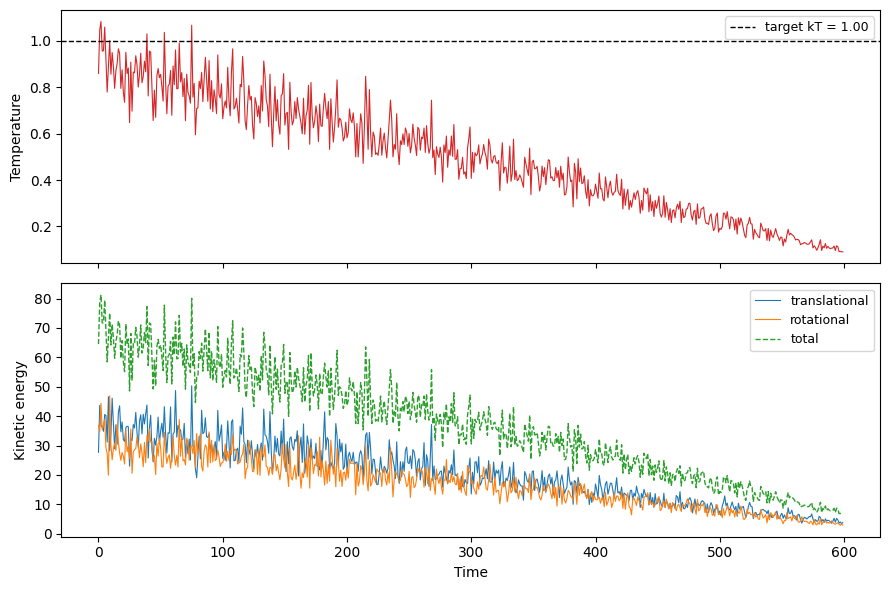

In [11]:
import matplotlib.pyplot as plt

# ── Temperature and kinetic energy diagnostics ────────────────────────────────
# Two-panel plot produced from the per-frame arrays collected during simulate_all.
#
# Panel 1 — Temperature vs time
#   Shows how quickly the thermostat equilibrates and whether it stays near target.
#   The dashed line marks the target kT value.
#   If temperature drifts far from target, try increasing gamma (stronger thermostat)
#   or reducing dt (more stable integration).
#
# Panel 2 — Kinetic energy vs time
#   Translational KE = 0.5 * Σ |p|² / M  (3N translational DOF → target = 1.5 N kT)
#   Rotational KE    = total KE − translational KE  (3N rotational DOF → target = 1.5 N kT)
#   Total KE         = translational + rotational     (target = 3 N kT)
#
#   It is normal for rotational KE to appear lower than translational KE in this
#   model: the patch masses are ~1e-8, giving a very small moment of inertia
#   (~2e-7).  The Langevin rotational relaxation time τ_rot = I/γ_rot is then
#   ~10⁻⁸, far shorter than dt = 10⁻³, so rotational DOF are overdamped and
#   do not thermalize correctly at this time step.

times = np.arange(n_chunks) * save_every * dt  # physical time for each saved frame

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(times, temp_arr, color='tab:red', lw=0.8)
ax1.axhline(kT(0.0), color='k', ls='--', lw=1.0, label=f'target kT = {kT(0.0):.2f}')
ax1.set_ylabel('Temperature')
ax1.legend(fontsize=9)

ax2.plot(times, ke_trans_arr, label='translational', color='tab:blue',   lw=0.8)
ax2.plot(times, ke_rot_arr,   label='rotational',    color='tab:orange',  lw=0.8)
ax2.plot(times, ke_trans_arr + ke_rot_arr, label='total', color='tab:green', ls='--', lw=1.0)
ax2.set_ylabel('Kinetic energy')
ax2.set_xlabel('Time')
ax2.legend(fontsize=9)

fig.tight_layout()
plt.show()

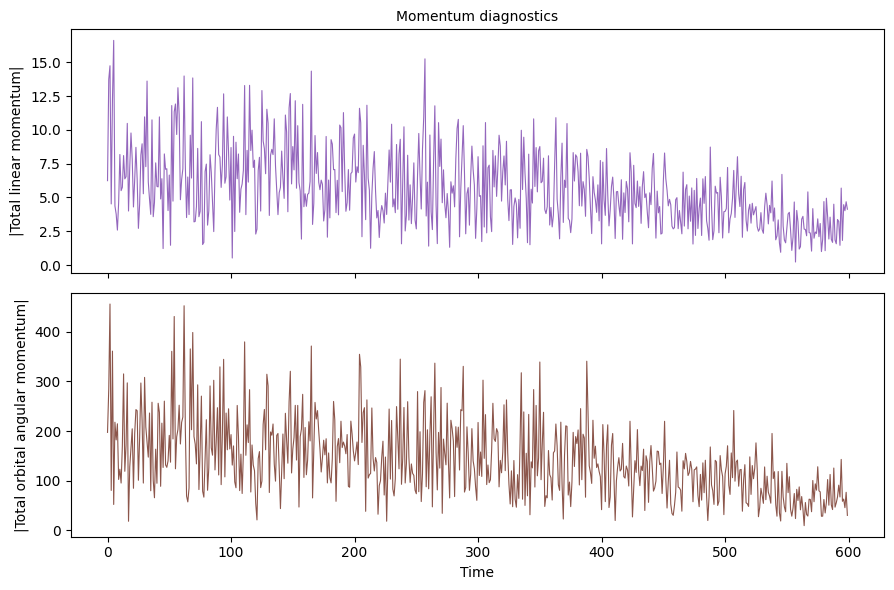

In [12]:
# ── Total momentum and angular momentum diagnostics ───────────────────────────
# Two-panel plot of conserved-quantity proxies over time.
#
# In a Langevin NVT simulation neither quantity is conserved — the thermostat
# applies momentum-altering random kicks at every step.  These plots therefore
# show the magnitude of fluctuations rather than a flat line.
#
# Panel 1 — |Total linear momentum|
#   P_total = Σ_i p_i^center  (sum of center momenta, shape (3,) per frame)
#   Should fluctuate symmetrically around zero; sustained drift would indicate
#   a bias in the integration or an error in the periodic boundary treatment.
#
# Panel 2 — |Total orbital angular momentum|
#   L_orbital = Σ_i r_i × p_i  (cross product of center positions × center momenta)
#   This captures the translational contribution to angular momentum about the
#   simulation-box origin.  Spin angular momentum from individual particle
#   rotations is excluded (it requires quaternion-to-body-frame conversion and
#   is typically much smaller for the heavy-center / light-patch mass ratio used
#   here).
#   Also expected to fluctuate around zero; large sustained offsets would
#   suggest a problem with the thermostat coupling to rotational DOF.

times = np.arange(n_chunks) * save_every * dt

p_mag = np.linalg.norm(p_total_arr,   axis=1)   # (n_chunks,) — |P_total|
L_mag = np.linalg.norm(L_orbital_arr, axis=1)   # (n_chunks,) — |L_orbital|

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(times, p_mag, color='tab:purple', lw=0.8)
ax1.set_ylabel('|Total linear momentum|')
ax1.set_title('Momentum diagnostics', fontsize=10)

ax2.plot(times, L_mag, color='tab:brown', lw=0.8)
ax2.set_ylabel('|Total orbital angular momentum|')
ax2.set_xlabel('Time')

fig.tight_layout()
plt.show()


In [98]:
site_positions[0].shape

(70, 3)

In [13]:
# Write the trajectory to an extended-XYZ file readable by Ovito, VESTA, and ASE.
#
# Each frame contains N*7 sites:
#   - 1 center per particle → type "A"  (large sphere)
#   - 6 patches per particle → type is the patch's color+complementarity string
#     (e.g. "RedA", "LimegreenB") taken from PATCH_TYPES.
#
# Ovito loading:
#   File → Load File → trajectory.xyz
#   Add "Assign Color" modifier and color by "Particle Type" to distinguish
#   each of the 30 patch types visually.  Particles with complementary types
#   that formed bonds will appear adjacent and paired in color.
traj = site_positions  # (n_frames, N*7, 3)

n_frames, n_sites, _ = traj.shape

# Build the per-site type label and display radius arrays.
# patch_assignments_np[i, j] is the species index (1..30) of patch j on particle i.
types = []
radii = []
for i in range(number_of_particles):
    types.append("A");       radii.append(RADIUS)   # central body site
    for j in range(6):
        species_idx = int(patch_assignments_np[i, j])  # 1..30
        types.append(PATCH_TYPES[species_idx - 1])      # e.g. "RedA"
        radii.append(0.5)

types = np.array(types)
radii = np.array(radii)

with open("trajectory.xyz", "w") as f:
    for t in range(n_frames):
        f.write(f"{n_sites}\n")
        f.write("Properties=species:S:1:pos:R:3:radius:R:1\n")
        for i in range(n_sites):
            x, y, z = traj[t, i]
            f.write(f"{types[i]} {x:.6f} {y:.6f} {z:.6f} {radii[i]}\n")

print(f"Wrote {n_frames} frames × {n_sites} sites to trajectory.xyz")

Wrote 600 frames × 175 sites to trajectory.xyz


In [ ]:
import scipy.special

# ── Tuneable parameters ───────────────────────────────────────────────────────
analysis_frame = -1          # frame index into site_positions (0=first, -1=last)
q4_r_cut       = float(RADIUS * 2 * 1.5)  # sigmoid midpoint, just past first neighbor shell
q4_r_width     = float(RADIUS * 0.5)      # sigmoid half-width; smaller → sharper transition
# ─────────────────────────────────────────────────────────────────────────────

# ── Extract center-of-mass positions for the 
# chosen frame ────────────────────
# Each particle contributes 7 sites; site 0 is the center, sites 1-6 are patches.
# Centers sit at indices 0, 7, 14, ... in the flat site array.
frame_all = site_positions[analysis_frame]          # (N*7, 3)
centers   = frame_all[::7]                          # (N, 3)
N_c       = len(centers)
bs        = float(box_size)

# ── Pairwise displacements with minimum-image PBC ────────────────────────────
diff  = centers[np.newaxis, :, :] - centers[:, np.newaxis, :]  # (N, N, 3)
diff  = diff - bs * np.round(diff / bs)
r_mat = np.linalg.norm(diff, axis=-1)                           # (N, N)
np.fill_diagonal(r_mat, np.inf)                                 # zero out self-pairs

# ── Sigmoidal bond weight ─────────────────────────────────────────────────────
# w(r) = 1 / (1 + exp((r − r_cut) / r_width))
# Approaches 1 for r << r_cut and 0 for r >> r_cut.
# This avoids the discontinuous force jump of a hard cutoff.
w_mat = 1.0 / (1.0 + np.exp((r_mat - q4_r_cut) / q4_r_width))  # (N, N)

# ── Spherical angles of each bond vector ─────────────────────────────────────
# scipy.special.sph_harm_y(1, m, phi_azimuthal, theta_polar):
#   phi_azimuthal  ∈ [-π, π]  — arctan2(y, x)
#   theta_polar    ∈ [0,  π]  — arccos(z / r)
with np.errstate(invalid='ignore'):
    cos_theta = np.clip(diff[:, :, 2] / r_mat, -1.0, 1.0)
theta_mat = np.arccos(cos_theta)                                # (N, N)
phi_mat   = np.arctan2(diff[:, :, 1], diff[:, :, 0])           # (N, N)

# ── Global Steinhardt Q4 ──────────────────────────────────────────────────────
# Q_{lm}  =  [ Σ_{i≠j} w(r_{ij}) Y_{lm}(r̂_{ij}) ]  /  [ Σ_{i≠j} w(r_{ij}) ]
# Q_l     =  sqrt( 4π/(2l+1) · Σ_{m=-l}^{l} |Q_{lm}|² )
#
# For a perfect FCC crystal Q4 ≈ 0.191; for a liquid Q4 ≈ 0.
# Values in between indicate partial order.
l       = 4
total_w = float(np.sum(w_mat))
Q_lm    = np.zeros(2 * l + 1, dtype=complex)

for mi, m in enumerate(range(-l, l + 1)):
    Y_lm      = scipy.special.sph_harm_y(1, m, phi_mat, theta_mat)  # (N, N), complex
    Q_lm[mi]  = np.sum(w_mat * Y_lm) / total_w

Q4 = float(np.sqrt(4.0 * np.pi / (2 * l + 1) * np.sum(np.abs(Q_lm) ** 2)))

print(f"Global Q4 = {Q4:.6f}")
print(f"  frame={analysis_frame},  r_cut={q4_r_cut:.3f},  r_width={q4_r_width:.3f},  N={N_c} particles")


Global Q4 = 0.294573
  frame=-1,  r_cut=7.500,  r_width=1.250,  N=25 particles


In [18]:
# ── Average coordination number ───────────────────────────────────────────────
# Reuses `analysis_frame` from the Q4 cell above.
#
# Sigmoid cutoff parameters are chosen so that a perfect simple-cubic assembly
# (6 nearest neighbors at r ≈ 2·RADIUS = 5.0, next-nearest at √2·5.0 ≈ 7.07)
# yields a coordination number slightly above 6:
#
#   w(r_NN  = 5.0)  ≈ 0.88  →  6 × 0.88 ≈ 5.3  from nearest neighbours
#   w(r_NNN = 7.07) ≈ 0.10  → 12 × 0.10 ≈ 1.2  from next-nearest
#   CN_SC ≈ 6.5  ✓
#
# Adjust cn_r_cut upward to count more NNN shells; reduce cn_r_width for a
# sharper transition (closer to a hard cutoff).
cn_r_cut   = float(RADIUS * 2 * 1.2)   # = 6.0  for RADIUS = 2.5
cn_r_width = float(RADIUS * 0.2)       # = 0.5  for RADIUS = 2.5

# Re-extract center positions for the chosen frame
centers_cn = site_positions[analysis_frame][::7]   # (N, 3)
N_cn       = len(centers_cn)
bs         = float(box_size)

# Pairwise distances with minimum-image PBC
diff_cn  = centers_cn[np.newaxis, :, :] - centers_cn[:, np.newaxis, :]  # (N, N, 3)
diff_cn  = diff_cn - bs * np.round(diff_cn / bs)
r_cn     = np.linalg.norm(diff_cn, axis=-1)                              # (N, N)
np.fill_diagonal(r_cn, np.inf)

# Sigmoidal weights (same functional form as the Q4 cell)
w_cn = 1.0 / (1.0 + np.exp((r_cn - cn_r_cut) / cn_r_width))            # (N, N)

# Per-particle coordination number: Z_i = Σ_{j≠i} w(r_{ij})
Z_per_particle = w_cn.sum(axis=1)                                        # (N,)
Z_avg          = float(Z_per_particle.mean())
Z_std          = float(Z_per_particle.std())

print(f"Average coordination number = {Z_avg:.3f}  ±  {Z_std:.3f}")
print(f"  frame={analysis_frame},  r_cut={cn_r_cut:.3f},  r_width={cn_r_width:.3f},  N={N_cn} particles")
print(f"  min={Z_per_particle.min():.2f}   max={Z_per_particle.max():.2f}")


Average coordination number = 3.747  ±  2.051
  frame=-1,  r_cut=6.000,  r_width=0.500,  N=25 particles
  min=0.00   max=8.47


In [19]:
# ── Trajectory loss toward a perfect SC assembly ─────────────────────────────
#
# L = (1/Np)(1/T) Σ_i Σ_t  w(t) [ (Q4_i(t) - Q4^sc)²  +  λ (Z_i(t) - z^target)² ]
#
# Q4_i(t):   per-particle Steinhardt Q4 at saved frame t
# Z_i(t):    per-particle coordination number at saved frame t
# w(t):      temporal sigmoid 1/(1+exp(-(t-t_nuc)/τ)) — zero-weights early frames
#            before nucleation so the loss focuses on the assembly phase
# Q4^sc:     analytical Q4 for a perfect simple-cubic crystal = sqrt(7/12) ≈ 0.764
#            (exact for 6 nearest-neighbour bonds along ±x,±y,±z; user estimate ~0.7)
# z^target:  6.0  (one bond per patch in a fully-assembled SC lattice)
#
# The function is written entirely in JAX, so jax.grad differentiates through it
# with respect to any of its arguments (traj_centers, t_nuc, tau_w, lam, …).

# ── Tuneable parameters ───────────────────────────────────────────────────────
Q4_sc    = jnp.float64(jnp.sqrt(7.0 / 12.0))  # ≈ 0.764  (exact SC value)
z_target = jnp.float64(6.0)
lam      = jnp.float64(1.0)           # λ: relative weight of CN vs Q4 term
t_nuc    = jnp.float64(max_time * 0.3)  # estimated nucleation time; tune from trajectory
tau_w    = jnp.float64(max_time * 0.1)  # temporal sigmoid half-width

# Bond sigmoid — same form used in the Q4 and CN analysis cells
loss_r_cut   = float(RADIUS * 2 * 1.2)   # = 6.0 for RADIUS=2.5
loss_r_width = float(RADIUS * 0.2)        # = 0.5

# ── JAX implementation of Y_{4m}, m = -4 … +4 ────────────────────────────────
# Expressed via cx = (dx + i·dy) so |cx|^k = sin^k(θ) — no pole singularity.
# All 9 components are complex; the real-valued Q4 is recovered via |·|².
def y4m_cartesian(dx, dy, dz):
    """
    Complex spherical harmonics Y_{4m}(r̂) for m = -4..+4.
    dx, dy, dz: unit-vector Cartesian components, shape (...).
    Returns: (..., 9) complex128.
    """
    cx  = dx.astype(complex) + 1j * dy.astype(complex)
    cx2, cx3, cx4 = cx**2, cx**3, cx**4
    z   = dz.astype(complex)
    z2, z3, z4 = z**2, z**3, z**4
    pi  = jnp.pi
    return jnp.stack([
        jnp.conj(cx4) * ( 3/16 * jnp.sqrt(35  / (2*pi))              ),  # m = -4
        jnp.conj(cx3) * ( 3/8  * jnp.sqrt(35  /    pi ) *  z         ),  # m = -3
        jnp.conj(cx2) * ( 3/8  * jnp.sqrt( 5  / (2*pi)) * (7*z2 - 1)),  # m = -2
        jnp.conj(cx ) * ( 3/8  * jnp.sqrt( 5  /    pi ) * (7*z3-3*z)),   # m = -1
                         ( 3/16 * jnp.sqrt( 1  /    pi ) * (35*z4 - 30*z2 + 3)),  # m = 0
               cx  *    (-3/8  * jnp.sqrt( 5  /    pi ) * (7*z3-3*z)),   # m = +1
               cx2 *    ( 3/8  * jnp.sqrt( 5  / (2*pi)) * (7*z2 - 1)),  # m = +2
               cx3 *    (-3/8  * jnp.sqrt(35  /    pi ) *  z         ),  # m = +3
               cx4 *    ( 3/16 * jnp.sqrt(35  / (2*pi))              ),  # m = +4
    ], axis=-1)  # (..., 9), complex128

# ── Per-particle Q4 and CN for a single frame ─────────────────────────────────
def _per_particle_q4_cn(centers):
    """
    centers: (N, 3) centre positions.
    Returns Q4_i (N,) and Z_i (N,), both real float64.
    """
    N   = centers.shape[0]
    bs  = jnp.float64(box_size)

    diff = centers[None, :, :] - centers[:, None, :]      # (N, N, 3)
    diff = diff - bs * jnp.round(diff / bs)                # minimum-image PBC
    r    = jnp.sqrt(jnp.sum(diff**2, axis=-1))            # (N, N)

    diag   = jnp.eye(N, dtype=bool)
    r      = jnp.where(diag, jnp.inf, r)                  # exclude self-pairs
    w_bond = 1.0 / (1.0 + jnp.exp((r - loss_r_cut) / loss_r_width))  # (N, N)

    # Unit vectors; self-direction zeroed so Y_{4m} contributes nothing
    r_nz  = jnp.where(diag, 1.0, r)
    unit  = diff / r_nz[:, :, None]
    unit  = jnp.where(diag[:, :, None], 0.0, unit)        # (N, N, 3)

    # Spherical harmonics for every directed bond
    Y     = y4m_cartesian(unit[..., 0], unit[..., 1], unit[..., 2])  # (N, N, 9)

    # Per-particle coordination number
    Z_i    = w_bond.sum(axis=1)                            # (N,)

    # Per-particle q_{4m} = Σ_j w_ij Y_{4m}(ij) / Σ_j w_ij
    Z_safe = jnp.maximum(Z_i, 1e-30)
    q_lm   = (w_bond[:, :, None].astype(complex) * Y).sum(axis=1) \
             / Z_safe[:, None].astype(complex)             # (N, 9)

    Q4_i   = jnp.sqrt(jnp.maximum(
        (4.0 * jnp.pi / 9.0) * jnp.sum(jnp.abs(q_lm)**2, axis=-1).real,
        0.0
    ))                                                     # (N,)
    return Q4_i, Z_i

# ── Differentiable trajectory loss ────────────────────────────────────────────
@jax.jit
def trajectory_loss(traj_centers, t_nuc, tau_w, lam, Q4_sc, z_target):
    """
    Scalar loss for an entire trajectory.

    traj_centers : (T, N, 3) — JAX array of centre positions at every saved frame
    t_nuc, tau_w : temporal sigmoid parameters (scalars)
    lam          : weight of CN term relative to Q4 term (scalar)
    Q4_sc        : target per-particle Q4 (scalar)
    z_target     : target coordination number (scalar)

    Memory: lax.scan processes one frame at a time → O(N²) working memory.
    Differentiable via jax.grad w.r.t. any argument.
    """
    T     = traj_centers.shape[0]
    times = jnp.arange(T, dtype=jnp.float64) * (save_every * dt)
    w_t   = 1.0 / (1.0 + jnp.exp(-(times - t_nuc) / tau_w))   # (T,)

    def scan_fn(_, inputs):
        centers_t, w = inputs
        Q4_i, Z_i  = _per_particle_q4_cn(centers_t)
        # (1/Np) Σ_i weighted squared residuals for this frame
        loss_q4_t = jnp.mean(w * (Q4_i - Q4_sc)**2)
        loss_z_t  = jnp.mean(w * (Z_i  - z_target)**2)
        return None, (loss_q4_t, loss_z_t)

    _, (per_frame_q4, per_frame_z) = lax.scan(scan_fn, None, (traj_centers, w_t))

    # (1/T) Σ_t — mean over frames completes the (1/Np)(1/T) double average
    return jnp.mean(per_frame_q4) + lam * jnp.mean(per_frame_z)

# ── Evaluate ──────────────────────────────────────────────────────────────────
traj_centers_jnp = jnp.array(site_positions[:, ::7, :])   # (T, N, 3)

print("Computing trajectory loss (JIT-compiling on first call)...")
loss_val = trajectory_loss(traj_centers_jnp, t_nuc, tau_w, lam, Q4_sc, z_target)
jax.block_until_ready(loss_val)
print(f"L = {float(loss_val):.6f}")
print(f"  Q4_sc={float(Q4_sc):.4f}  z_target={float(z_target):.1f}  λ={float(lam):.2f}")
print(f"  t_nuc={float(t_nuc):.1f}  τ={float(tau_w):.1f}  frames={traj_centers_jnp.shape[0]}")

# Gradient w.r.t. t_nuc: how sensitive the loss is to the estimated nucleation time.
# jax.grad works on any scalar argument; argnums selects which one.
dL_dt_nuc = jax.grad(trajectory_loss, argnums=1)(
    traj_centers_jnp, t_nuc, tau_w, lam, Q4_sc, z_target
)
print(f"\n∂L/∂t_nuc = {float(dL_dt_nuc):.6e}  (demonstrating JAX differentiability)")


Computing trajectory loss (JIT-compiling on first call)...
L = 8.209702
  Q4_sc=0.7638  z_target=6.0  λ=1.00
  t_nuc=180.0  τ=60.0  frames=600

∂L/∂t_nuc = -2.777524e-02  (demonstrating JAX differentiability)


## Ensemble Loss

Run `number_of_simulations` independent simulations with identical parameters, compute the trajectory loss for each, and return the average.  The bond-energy array `D0_colors = [D0_red, D0_blue]` is fully differentiable: `jax.value_and_grad` flows gradients back through every Langevin step via reverse-mode AD on `lax.scan`.

In [20]:
# ── Ensemble configuration ────────────────────────────────────────────────────
number_of_simulations = 4
ens_base_key          = random.PRNGKey(42)

# (2,) bond-energy array [D0_red, D0_blue] — the parameter to be optimised.
# D0_colors[0] scales the Morse well depth for Red A↔B bonds.
# D0_colors[1] scales the Morse well depth for Blue A↔B bonds.
D0_colors = jnp.array([10.0, 10.0])

# ── Simulation knobs (independent of the exploration cells above) ─────────────
ens_N          = 20             # particles per simulation
ens_phi        = 0.05           # volume packing fraction
ens_dt         = 1e-3
ens_num_steps  = int(3e4)       # 30k steps — short enough for tractable AD gradients
ens_save_every = int(5e2)       # → 60 saved frames per simulation
ens_n_chunks   = ens_num_steps // ens_save_every
ens_max_time   = ens_num_steps * ens_dt
ens_kT_fn      = lambda t: 1.0 + (0.1 - 1.0) * (t / ens_max_time)
ens_gamma_val  = 5.0

# ── Loss hyper-parameters ─────────────────────────────────────────────────────
ens_Q4_sc    = jnp.float64(jnp.sqrt(7.0 / 12.0))  # exact SC Q4 ≈ 0.764
ens_z_target = jnp.float64(6.0)
ens_lam      = jnp.float64(1.0)
ens_t_nuc    = jnp.float64(ens_max_time * 0.3)
ens_tau_w    = jnp.float64(ens_max_time * 0.1)

# ── Gradient-descent settings ─────────────────────────────────────────────────
n_gd_steps = 20
gd_lr      = 0.5    # learning rate; scale down if loss diverges

# ── Static geometry and space ─────────────────────────────────────────────────
ens_box_size             = float(get_box_size(ens_phi, ens_N, RADIUS))
ens_disp_fn, ens_shift_fn = space.periodic(ens_box_size)
ens_gamma_rb             = rigid_body.RigidBody(
    jnp.array([ens_gamma_val]), jnp.array([3.0 * ens_gamma_val])
)
print(f"Ensemble box size: {ens_box_size:.3f}")

# ── Particle types — Red and Blue patches only ────────────────────────────────
# Four prototypes: all-RedA, all-RedB, all-BlueA, all-BlueB (×2 each = 8 types).
# Equal mix ensures both Red A↔B and Blue A↔B bonds are present so that
# gradient descent can meaningfully tune both entries of D0_colors.
ENS_TYPE_NAMES = [
    ["RedA",  "RedA",  "RedA",  "RedA",  "RedA",  "RedA" ],
    ["RedA",  "RedA",  "RedA",  "RedA",  "RedA",  "RedA" ],
    ["RedB",  "RedB",  "RedB",  "RedB",  "RedB",  "RedB" ],
    ["RedB",  "RedB",  "RedB",  "RedB",  "RedB",  "RedB" ],
    ["BlueA", "BlueA", "BlueA", "BlueA", "BlueA", "BlueA"],
    ["BlueA", "BlueA", "BlueA", "BlueA", "BlueA", "BlueA"],
    ["BlueB", "BlueB", "BlueB", "BlueB", "BlueB", "BlueB"],
    ["BlueB", "BlueB", "BlueB", "BlueB", "BlueB", "BlueB"],
]
ENS_TYPE_SPECIES = np.array([
    [PATCH_TYPES.index(name) + 1 for name in t] for t in ENS_TYPE_NAMES
], dtype=np.int32)  # (8, 6)

ens_patch_key        = random.fold_in(ens_base_key, 99)
ens_type_indices     = np.array(
    random.randint(ens_patch_key, (ens_N,), minval=0, maxval=8)
)
ens_patch_assignments = ENS_TYPE_SPECIES[ens_type_indices]   # (ens_N, 6)
ens_center_col        = np.zeros((ens_N, 1), dtype=np.int32)
ens_flat_species      = jnp.array(
    np.concatenate([ens_center_col, ens_patch_assignments], axis=1)
).reshape(-1)                                                  # (ens_N * 7,)

# ── Unit Morse epsilon matrices (D0 = 1.0) ────────────────────────────────────
# The total Morse energy is  E = D0_colors[0]*E_red_unit + D0_colors[1]*E_blue_unit.
# This linear decomposition is the key to differentiability: jax.grad sees
# D0_colors as a plain scalar multiplier — no need to recompile when D0 changes.
red_A,  red_B  = 2*(COLORS.index("Red") +1)-1, 2*(COLORS.index("Red") +1)   # 7, 8
blue_A, blue_B = 2*(COLORS.index("Blue")+1)-1, 2*(COLORS.index("Blue")+1)   # 5, 6

ens_morse_eps_red  = (jnp.zeros((N_SPECIES, N_SPECIES))
                      .at[red_A,  red_B ].set(1.0).at[red_B,  red_A ].set(1.0))
ens_morse_eps_blue = (jnp.zeros((N_SPECIES, N_SPECIES))
                      .at[blue_A, blue_B].set(1.0).at[blue_B, blue_A].set(1.0))
ens_lj_eps         = jnp.zeros((N_SPECIES, N_SPECIES)).at[0, 0].set(1.0)

# ── Cutoffs ───────────────────────────────────────────────────────────────────
ens_lj_sigma  = float(RADIUS * 2.0)
ens_lj_rc     = min(2.5 * ens_lj_sigma, ens_box_size * 0.45)
ens_lj_ro     = 0.8  * ens_lj_rc
ens_morse_rc  = min(3.0, ens_box_size * 0.45)
ens_morse_ro  = 0.85 * ens_morse_rc

# ── Neighbor list ─────────────────────────────────────────────────────────────
ens_neighbor_fn = partition.neighbor_list(
    ens_disp_fn, ens_box_size, ens_lj_rc,
    dr_threshold=0.5, capacity_multiplier=1.75,
    format=partition.OrderedSparse,
)

# ── Unit pair energy functions ────────────────────────────────────────────────
ens_lj_fn = smap.pair_neighbor_list(
    energy.multiplicative_isotropic_cutoff(energy.lennard_jones, ens_lj_ro, ens_lj_rc),
    space.canonicalize_displacement_or_metric(ens_disp_fn),
    ignore_unused_parameters=True, species=2,
    sigma=ens_lj_sigma, epsilon=ens_lj_eps,
)
ens_morse_red_fn = smap.pair_neighbor_list(
    energy.multiplicative_isotropic_cutoff(energy.morse, ens_morse_ro, ens_morse_rc),
    space.canonicalize_displacement_or_metric(ens_disp_fn),
    ignore_unused_parameters=True, species=2,
    sigma=0.0, epsilon=ens_morse_eps_red, alpha=5.0,
)
ens_morse_blue_fn = smap.pair_neighbor_list(
    energy.multiplicative_isotropic_cutoff(energy.morse, ens_morse_ro, ens_morse_rc),
    space.canonicalize_displacement_or_metric(ens_disp_fn),
    ignore_unused_parameters=True, species=2,
    sigma=0.0, epsilon=ens_morse_eps_blue, alpha=5.0,
)

# rb_neighbor_fn: patches nbrs.update to accept RigidBody (reuses placeholder energy)
def _ens_placeholder_energy(R, neighbor, **kwargs):
    return ens_lj_fn(R, neighbor=neighbor, species=ens_flat_species)

ens_rb_neighbor_fn, _ = rigid_body.point_energy_neighbor_list(
    _ens_placeholder_energy, ens_neighbor_fn, oct_shape
)

print(f"Red  species: {red_A}(A) / {red_B}(B)")
print(f"Blue species: {blue_A}(A) / {blue_B}(B)")
print(f"Particle type distribution: {dict(zip(*np.unique(ens_type_indices, return_counts=True)))}")


Ensemble box size: 29.693
Red  species: 7(A) / 8(B)
Blue species: 5(A) / 6(B)
Particle type distribution: {np.int64(0): np.int64(1), np.int64(1): np.int64(3), np.int64(2): np.int64(5), np.int64(3): np.int64(5), np.int64(4): np.int64(2), np.int64(5): np.int64(1), np.int64(6): np.int64(2), np.int64(7): np.int64(1)}


In [21]:
# ── Initial configurations ────────────────────────────────────────────────────
# Each simulation starts from an independently FIRE-minimised configuration
# so that ensemble averaging reduces variance from the initial condition.
def make_ens_initial_config(key):
    """FIRE minimisation → (RigidBody, neighbor_list) ready for Langevin dynamics."""
    pos       = random.uniform(key, (ens_N, 3), minval=0.0, maxval=ens_box_size)
    soft_e_fn = energy.soft_sphere_pair(ens_disp_fn, sigma=RADIUS * 2)
    init_fn, apply_fn = minimize.fire_descent(soft_e_fn, ens_shift_fn)
    state     = lax.fori_loop(0, 5000, jit(lambda i, s: apply_fn(s)), init_fn(pos))
    init_rb   = rigid_body.RigidBody(
        center=state.position,
        orientation=rigid_body.Quaternion(
            jnp.array([[0, 0, 6e-01, 8e-01]] * ens_N)
        ),
    )
    init_nbrs = ens_rb_neighbor_fn.allocate(init_rb)
    return init_rb, init_nbrs

ens_init_configs = [
    make_ens_initial_config(random.fold_in(ens_base_key, i))
    for i in range(number_of_simulations)
]
# Separate keys for Langevin noise (independent of initialisation key)
ens_sim_keys = [random.fold_in(ens_base_key, 100 + i) for i in range(number_of_simulations)]

print(f"Created {number_of_simulations} initial configurations.")


/Users/paarthtara/Desktop/jax-md-project/.venv/lib/python3.13/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


Created 4 initial configurations.


In [22]:
# ── Per-particle Q4 / CN for ensemble (uses ens_box_size) ────────────────────
_ens_r_cut   = float(RADIUS * 2 * 1.2)
_ens_r_width = float(RADIUS * 0.2)

def _ens_q4_cn(centers):
    """Per-particle Q4 and CN; identical to _per_particle_q4_cn but with ens_box_size."""
    N   = centers.shape[0]
    bs  = jnp.float64(ens_box_size)
    diff = centers[None] - centers[:, None]
    diff = diff - bs * jnp.round(diff / bs)
    r    = jnp.sqrt(jnp.sum(diff**2, axis=-1))
    diag   = jnp.eye(N, dtype=bool)
    r      = jnp.where(diag, jnp.inf, r)
    w_bond = 1.0 / (1.0 + jnp.exp((r - _ens_r_cut) / _ens_r_width))
    r_nz   = jnp.where(diag, 1.0, r)
    unit   = diff / r_nz[:, :, None]
    unit   = jnp.where(diag[:, :, None], 0.0, unit)
    Y      = y4m_cartesian(unit[..., 0], unit[..., 1], unit[..., 2])
    Z_i    = w_bond.sum(axis=1)
    q_lm   = (w_bond[:, :, None].astype(complex) * Y).sum(axis=1) \
             / jnp.maximum(Z_i, 1e-30)[:, None].astype(complex)
    Q4_i   = jnp.sqrt(jnp.maximum(
        (4.0 * jnp.pi / 9.0) * jnp.sum(jnp.abs(q_lm)**2, axis=-1).real, 0.0
    ))
    return Q4_i, Z_i


# ── Single simulation → scalar loss (differentiable w.r.t. D0_colors) ─────────
#
# Energy decomposition: E = E_lj  +  D0_colors[0]·E_red_unit  +  D0_colors[1]·E_blue_unit
# is linear in D0_colors, so jax.grad sees a plain multiply — fully differentiable.
# Gradients propagate back through every Langevin step via lax.scan's built-in VJP.
def simulate_one_and_loss(D0_colors, sim_key, init_rb, init_nbrs):
    # D0_colors-parameterised energy function (closes over D0_colors as a traced value)
    def energy_fn(body, neighbor, **kwargs):
        R = vmap(rigid_body.transform, (0, None))(body, oct_shape).reshape(-1, 3)
        return (
            ens_lj_fn(R, neighbor=neighbor, species=ens_flat_species)
            + D0_colors[0] * ens_morse_red_fn( R, neighbor=neighbor, species=ens_flat_species)
            + D0_colors[1] * ens_morse_blue_fn(R, neighbor=neighbor, species=ens_flat_species)
        )

    init_fn, step_fn = simulate.nvt_langevin(
        energy_fn, ens_shift_fn, ens_dt, ens_kT_fn(0.0), gamma=ens_gamma_rb
    )
    state = init_fn(sim_key, init_rb, mass=oct_shape.mass(), neighbor=init_nbrs)

    def outer_step(carry, _):
        state, nbrs, step_count = carry

        def inner_step(carry, _):
            state, nbrs, step_count = carry
            t         = step_count * ens_dt
            nbrs      = nbrs.update(state.position)
            new_state = step_fn(state, neighbor=nbrs, kT=ens_kT_fn(t))
            return (new_state, nbrs, step_count + 1), None

        (new_state, new_nbrs, new_sc), _ = lax.scan(
            inner_step, (state, nbrs, step_count), None, length=ens_save_every
        )
        frame = vmap(rigid_body.transform, (0, None))(
            new_state.position, oct_shape
        ).reshape(ens_N * 7, 3)
        return (new_state, new_nbrs, new_sc), frame

    (_, _, _), frames = lax.scan(
        outer_step, (state, init_nbrs, jnp.zeros((), dtype=jnp.int32)),
        None, length=ens_n_chunks
    )

    # Trajectory loss (inline — uses ens_ time params rather than the global ones)
    traj_centers = frames[:, ::7, :]                               # (T, N, 3)
    T     = traj_centers.shape[0]
    times = jnp.arange(T, dtype=jnp.float64) * (ens_save_every * ens_dt)
    w_t   = 1.0 / (1.0 + jnp.exp(-(times - ens_t_nuc) / ens_tau_w))

    def scan_loss(_, inputs):
        centers_t, w = inputs
        Q4_i, Z_i   = _ens_q4_cn(centers_t)
        return None, (
            jnp.mean(w * (Q4_i - ens_Q4_sc)**2),
            jnp.mean(w * (Z_i  - ens_z_target)**2),
        )

    _, (pq4, pz) = lax.scan(scan_loss, None, (traj_centers, w_t))
    return jnp.mean(pq4) + ens_lam * jnp.mean(pz)


# ── Ensemble loss: mean over all simulations ──────────────────────────────────
def ensemble_loss(D0_colors):
    """Average trajectory loss over number_of_simulations independent runs."""
    losses = [
        simulate_one_and_loss(D0_colors, key, rb, nb)
        for key, (rb, nb) in zip(ens_sim_keys, ens_init_configs)
    ]
    return jnp.mean(jnp.stack(losses))


# ── Evaluate initial ensemble loss ───────────────────────────────────────────
print("Evaluating initial ensemble loss (JIT-compiling on first call — may take a moment)...")
L0 = ensemble_loss(D0_colors)
jax.block_until_ready(L0)
print(f"Initial ensemble loss  L = {float(L0):.6f}   D0_colors = {np.array(D0_colors)}")


# ── Gradient descent on D0_colors ────────────────────────────────────────────
# jax.value_and_grad differentiates ensemble_loss w.r.t. D0_colors (argnums=0 default).
# The gradient flows back through every Langevin step in every simulation.
# After the first call compiles the value+grad graph, subsequent steps are fast.
val_and_grad_fn = jax.jit(jax.value_and_grad(ensemble_loss))

print(f"\nGradient descent ({n_gd_steps} steps, lr={gd_lr}):")
for step in range(n_gd_steps):
    loss_val, grad = val_and_grad_fn(D0_colors)
    D0_colors      = D0_colors - gd_lr * grad
    D0_colors      = jnp.clip(D0_colors, 0.1, 200.0)  # keep well depths positive
    jax.block_until_ready(D0_colors)
    print(f"  step {step:3d}: L = {float(loss_val):.6f}   "
          f"D0 = [{float(D0_colors[0]):.4f}, {float(D0_colors[1]):.4f}]   "
          f"grad = [{float(grad[0]):.3e}, {float(grad[1]):.3e}]")

print(f"\nOptimised D0_colors = {np.array(D0_colors)}")


Evaluating initial ensemble loss (JIT-compiling on first call — may take a moment)...
Initial ensemble loss  L = 19.562795   D0_colors = [10. 10.]

Gradient descent (20 steps, lr=0.5):


: 